In [3]:
# Imports
import os
import sys
from IPython.display import display

from py_scripts.parser_registry import parse_files, list_parsers

# Backend selection ('music21' | 'partitura')
PARSING_BACKEND = 'music21'

# Configuration
FILTER_ZERO_DURATION = True # filter out notes with duration 0 (grace notes)
ADJUST_FRACTIONAL_DURATION = True # rounds Duration, Local Onset, and Global Onset to 3 decimals
PARSE_ENHARMONIC = True     # add 'Pitch Enharmonic' column grounded in source notation
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

SHOW_MEASURE_LINES = True   # draw vertical measure lines at measure starts
MEASURE_LINE_COLOR = 'black'  # color for the measure lines

HOVER_ENABLED = True        # enable hover tool (Bokeh only)
HOVER_FIELDS = ['measure', 'local_onset', 'global_onset', 'duration', 'pitch', 'pitch_enharmonic', 'midi', 'voice', 'xml_id'] # hover options as list

DISPLAY_PREVIEW = True      # show a preview of the parsed data as df
PREVIEW_ROWS = 20          # number of rows to show in the preview

CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'
STRIP_TIES = True           # merge tied notes into single notes (music21 backend only)
ALIGN_ACCIDENT_SCHEMA = True # align accidentals on both parsing backends to the same schema (Pitch Enharmonic is parsed only in b/# format)

COLORIZE_VOICES = True      # color-code notes by voice/part in the piano roll
PALETTE = 'Category20'      # palette name ('Category10'/'tab10', 'Category20'/'tab20', 'Set3', or a list)
INCLUDE_XML_IDS = True      # if MEI, include xml:id per note as 'xml_id' column

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    #'https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn',
    #'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc1f22.krn',
    # 'https://raw.githubusercontent.com/trompamusic-encodings/Beethoven_Op31_No3_HenleUrtext/refs/heads/master/Beethoven_Op31_No3_3-HenleUrtext.mei'
    # 'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml'
    'https://raw.githubusercontent.com/music-encoding/sample-encodings/main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc2f05.krn',
    # 'C:/Users/egorp/OneDrive/Desktop/weimar_ftp_backup/dokuwiki/database/05/CaSe_11_UNSP_UNSP_Danksagenw_005_00011.xml'  # If you prefer backslashes, make it a raw string: r'C:\Users\egorp\...'
]

# Plot sizing
PLOT_SIZE_X = 900  # width in pixels
PLOT_SIZE_Y = 600   # height in pixels

# Zoom tool dimensions: 'both' | 'width' (x-only) | 'height' (y-only)
# Bokeh only!
ZOOM_DRAG_DIM = 'both'
ZOOM_WHEEL_DIM = 'width'

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    parsing_backend=PARSING_BACKEND,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    parse_enharmonic=PARSE_ENHARMONIC,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    measure_line_color=MEASURE_LINE_COLOR,
    show_hover=HOVER_ENABLED,
    hover_fields=HOVER_FIELDS,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
    strip_ties=STRIP_TIES,
    align_accident_schema=ALIGN_ACCIDENT_SCHEMA,
    colorize_voices=COLORIZE_VOICES,
    palette=PALETTE,
    include_xml_ids=INCLUDE_XML_IDS
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}")


Processing (music21): Bach-JS_Ein_feste_Burg.mei -> 00_bach_js_ein_feste_burg


c:\Users\egorp\miniconda3\envs\py312latest\Lib\site-packages\partitura\io\importmei.py:255: UserWarning: The key signature is not encoded in None or in any ancestor scoreDef.
  warnings.warn(
c:\Users\egorp\miniconda3\envs\py312latest\Lib\site-packages\partitura\io\importmei.py:258: UserWarning: A default key signature of C maj is set.
  warnings.warn("A default key signature of C maj is set.")


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
0,0,0.0,0.0,1.0,D5,D5,74,2427879038592 / Voice 1,d1e366
1,0,0.0,0.0,1.0,A4,A4,69,2427879038592 / Voice 2,NaN
2,0,0.0,0.0,1.0,F4,F4,65,2427879038592 / Voice 1,d1e54
3,0,0.0,0.0,0.5,D4,D4,62,2427879038592 / Voice 2,NaN
4,0,0.5,0.5,0.5,C4,C4,60,2427879038592 / Voice 2,NaN
5,1,0.0,1.0,1.0,D5,D5,74,2427879038592 / Voice 1,d1e390
6,1,0.0,1.0,1.0,D4,D4,62,2427879038592 / Voice 2,NaN
7,1,0.0,1.0,1.0,F4,F4,65,2427879038592 / Voice 1,NaN
8,1,0.0,1.0,1.0,B3,B3,59,2427879038592 / Voice 2,NaN
9,1,1.0,2.0,1.0,D5,D5,74,2427879038592 / Voice 1,NaN


Rows: 235, unique pitches: 25
Parsed DataFrames:
- 00_bach_js_ein_feste_burg: rows=235, unique_pitches=25, min_duration=0.25


In [4]:
url = FILE_SOURCES[1]

IndexError: list index out of range

In [ ]:
from py_scripts import vrv_set_options, vrv_load_from_url, vrv_debug_info

vrv_set_options(breaks="none", scale=40)
vrv_load_from_url(url)  # or your current load step

info = vrv_debug_info()
for k, v in info.items():
    print(k, "=>", v)

verovio_package_file => c:\Users\egorp\miniconda3\envs\py312latest\Lib\site-packages\verovio\__init__.py
version => 5.6.0[undefined]
pages => 1
options_raw => {'adjustPageHeight': True, 'adjustPageWidth': False, 'appXPathQuery': [], 'barLineSeparation': 0.8, 'barLineWidth': 0.3, 'beamFrenchStyle': False, 'beamMaxSlope': 10, 'beamMixedPreserve': False, 'beamMixedStemMin': 3.5, 'bottomMarginArtic': 0.75, 'bottomMarginHarm': 1.0, 'bottomMarginHeader': 2.0, 'bottomMarginOctave': 1.0, 'bracketThickness': 1.0, 'breaks': 'none', 'breaksNoWidow': False, 'breaksSmartSb': 0.66, 'choiceXPathQuery': [], 'condense': 'auto', 'condenseFirstPage': False, 'condenseNotLastSystem': False, 'condenseTempoPages': False, 'dashedBarLineDashLength': 1.14, 'dashedBarLineGapLength': 1.14, 'defaultBottomMargin': 0.5, 'defaultLeftMargin': 0.0, 'defaultRightMargin': 0.0, 'defaultTopMargin': 0.5, 'durationEquivalence': 'brevis', 'dynamDist': 1.0, 'dynamSingleGlyphs': False, 'engravingDefaults': {}, 'evenNoteSpacing'

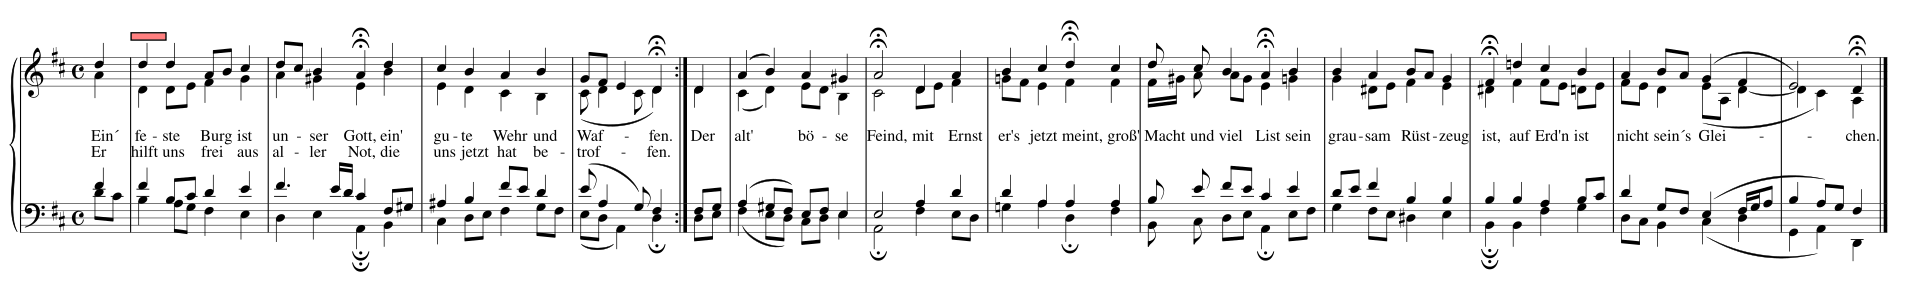

In [ ]:
from py_scripts import (
    vrv_set_options, vrv_load_from_url, vrv_render_all_pages, vrv_display_svg,
    vrv_insert_annot
)

vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none")
vrv_load_from_url(url)

vrv_insert_annot(
    text="Match A",
    type="score",
    staff="1",
    tstamp="0",
    tstamp2="2",
    measure_index=2
)

for svg in vrv_render_all_pages():
    vrv_display_svg(svg)

In [ ]:
# import os, datetime
# from py_scripts import vrv_get_mei

# os.makedirs("exports", exist_ok=True)
# ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# out_path = f"exports/score_with_annot_{ts}.mei"

# with open(out_path, "w", encoding="utf-8", newline="\n") as f:
#     f.write(vrv_get_mei())

# print("Saved:", out_path)